In [34]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from arch.unitroot import VarianceRatio
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [3]:
df = yf.download("CAD=X", start="2007-01-01", end="2012-12-31")
df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2007-01-01,1.1643,1.1664,1.1608,1.1660,0
2007-01-02,1.1648,1.1657,1.1625,1.1645,0
2007-01-03,1.1726,1.1735,1.1637,1.1646,0
2007-01-04,1.1776,1.1777,1.1713,1.1725,0
2007-01-05,1.1738,1.1785,1.1716,1.1775,0


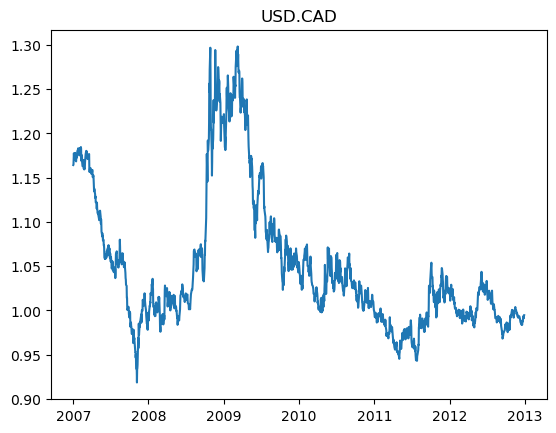

In [5]:
plt.plot( df["Close"])
plt.title("USD.CAD")
plt.show()

In [6]:
close = df["Close"].dropna()
close.head()

Date
2007-01-01    1.1643
2007-01-02    1.1648
2007-01-03    1.1726
2007-01-04    1.1776
2007-01-05    1.1738
Name: Close, dtype: float64

### Augumented Dicky-fuller test

In [7]:
result_k0 = adfuller(close, maxlag=0, regression="c")

In [8]:
print(f"ADF statistic: {result_k0[0]:.4f}")
print(f"p-value: {result_k0[1]:.4f}")
print(f"lags used: {result_k0[2]}")
print(f"n observations: {result_k0[3]}")
print(f"critical values: {result_k0[4]}")

ADF statistic: -2.1929
p-value: 0.2088
lags used: 0
n observations: 1556
critical values: {'1%': np.float64(-3.4345595891554566), '5%': np.float64(-2.863399278674411), '10%': np.float64(-2.5677598491451947)}


- adfuller tests H0: the series has a unit root (i.e., it's a random walk — non-stationary, no tendency to revert to a mean). H1: the series is stationary (mean-reverting).
- regression='c' — include a constant (nonzero mean/offset, since USD/CAD's long-run average is nowhere near zero) but no linear time-trend term (since we're not assuming price systematically drifts up or down over time, just fluctuates around some level).
- maxlag=0 — the simplest version of the test, no lagged difference terms included to account for serial correlation in the price changes themselves.
- The ADF statistic — a more negative number is more evidence against the unit root (more evidence of stationarity/mean-reversion). Compare it against the critical values dict: if your statistic is more negative than the critical value at (say) the 5% level, you reject H0 — evidence of stationarity.
- The p-value — same logic as always: small p (< 0.05 conventionally) → reject H0 → evidence of stationarity. Large p → fail to reject → looks like a random walk.

In [9]:
result_k1 = adfuller(close, maxlag=1, regression="c", autolag=None)

print(f"ADF statistic: {result_k1[0]:.4f}")
print(f"p-value: {result_k1[1]:.4f}")
print(f"lags used: {result_k1[2]}")
print(f"n observations: {result_k1[3]}")
print(f"critical values: {result_k1[4]}")

ADF statistic: -2.1920
p-value: 0.2091
lags used: 1
n observations: 1555
critical values: {'1%': np.float64(-3.4345623007753496), '5%': np.float64(-2.8634004754910296), '10%': np.float64(-2.567760486450719)}


**conclusion for both tests**
- H0: USD/CAD (2007–2012) has a unit root (non-stationary/random walk).
- H1: USD/CAD is stationary (mean-reverting).
- k=0: fail to reject (p=0.209). k=1: fail to reject (p=0.209). No evidence of mean-reversion in this window at either lag.

### Hurst Exponent

For a given moment order q and a lag r, you compute the q-th moment of the |price change over lag r|, then see how that scales as r grows. If <|x(t+r)-x(t)|^q> ~ r^(qH(q)), then plotting log(<|Δx_r|^q>) against log(r) gives a straight line with slope qH(q) — divide by q to recover H(q).

In [30]:
x = np.log(close.values)
n = len(x)

lags = range(2,100)
q_list = [1,2,3,4,5]

def hurst_q(x, q_list, lags):
    H = {}
    for q in q_list:
        tau = []
        for lag in lags:
            diffs = np.abs(x[lag:] - x[:-lag]) ** q
            tau.append(np.mean(diffs))
        tau = np.array(tau)
        log_lags = np.log(list(lags))
        log_tau = np.log(tau)
        slope, intercept = np.polyfit(log_lags, log_tau, 1)
        H[q] = slope/q
    return H

H_results = hurst_q(x, q_list, lags)
for q, h in H_results.items():
    print(f"q = {q}, H(q) = {h:.4f}")

q = 1, H(q) = 0.4986
q = 2, H(q) = 0.4881
q = 3, H(q) = 0.4670
q = 4, H(q) = 0.4395
q = 5, H(q) = 0.4134


#### Testing Function
- Brownian motion / random walk → theoretically \(H \approx 0.5\)
- Mean-reverting process → \(H < 0.5\)
Trending / persistent process → H>0.5

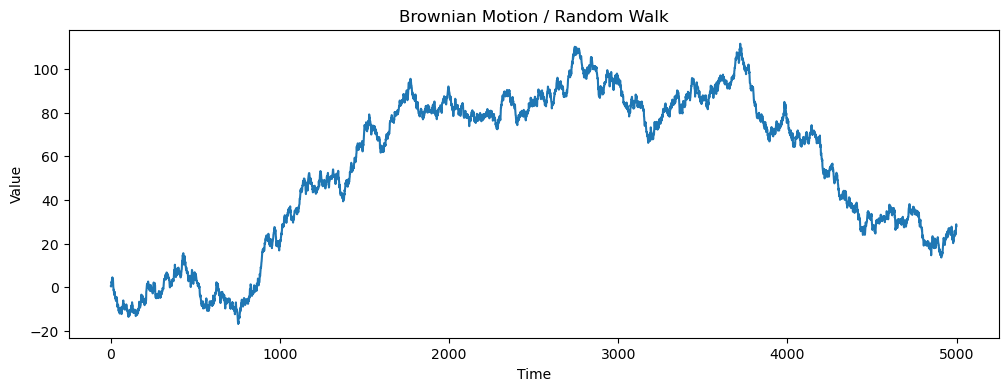

In [15]:
np.random.seed(42)

n = 5000

returns =  np.random.normal(0,1,n)
brownian = np.cumsum(returns)
plt.figure(figsize=(12, 4))
plt.plot(brownian)
plt.title("Brownian Motion / Random Walk")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

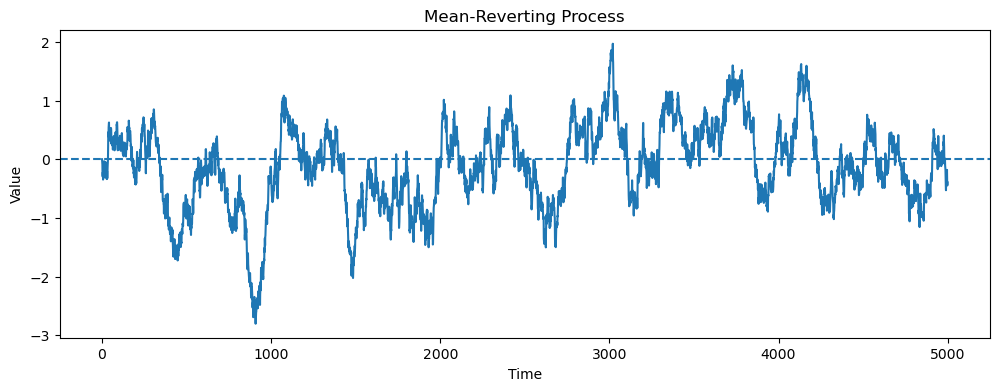

In [16]:
theta = 0.8      # strength of mean reversion
mu = 0.0         # long-term mean
sigma = 1.0
dt = 0.01

mean_reverting = np.zeros(n)

for t in range(1, n):
    noise = np.random.normal()
    mean_reverting[t] = (
        mean_reverting[t-1]
        + theta * (mu - mean_reverting[t-1]) * dt
        + sigma * np.sqrt(dt) * noise
    )

plt.figure(figsize=(12, 4))
plt.plot(mean_reverting)
plt.axhline(mu, linestyle="--")
plt.title("Mean-Reverting Process")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

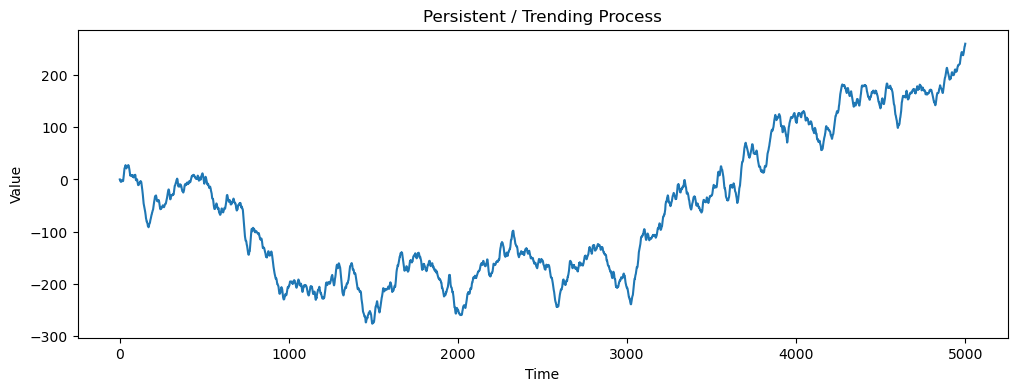

In [17]:
phi = 0.8

returns = np.zeros(n)
noise = np.random.normal(0, 1, n)

for t in range(1, n):
    returns[t] = phi * returns[t-1] + noise[t]

trending = np.cumsum(returns)

plt.figure(figsize=(12, 4))
plt.plot(trending)
plt.title("Persistent / Trending Process")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [27]:
print("Brownian Hurst:", hurst_q(brownian,q_list, lags)[1])

Brownian Hurst: 0.5179153809417784


In [26]:
print("Mean-reverting Hurst:", hurst_q(mean_reverting,q_list, lags)[1])

Mean-reverting Hurst: 0.47024879206200426


In [25]:
print("Trending Hurst:", hurst_q(trending,q_list, lags)[1])

Trending Hurst: 0.6110332808295057


### Variance Ratio Test

Under a true random walk, variance scales linearly with time — Var(x(t+q) - x(t)) = q · Var(x(t+1) - x(t)). The variance ratio test checks whether that holds:

In [33]:
for lag in [2, 5, 10, 20, 30]:
    vr = VarianceRatio(x, lags=lag, trend='c')  # trend='c' = allow nonzero drift, matches ADF setup
    print(f"lags={lag}: stat={vr.stat:.4f}, p-value={vr.pvalue:.4f}, VR={vr.vr:.4f}")

lags=2: stat=-0.4763, p-value=0.6338, VR=0.9827
lags=5: stat=0.2538, p-value=0.7996, VR=1.0204
lags=10: stat=-0.0150, p-value=0.9880, VR=0.9981
lags=20: stat=-0.5062, p-value=0.6127, VR=0.9080
lags=30: stat=-0.7863, p-value=0.4317, VR=0.8245


- VR(q) = 1 → consistent with random walk.
- VR(q) > 1 → variance grows faster than linear → trending/momentum (positive autocorrelation in returns).
- VR(q) < 1 → variance grows slower than linear → mean-reverting (negative autocorrelation in returns).

- H0: USD/CAD log-price increments are uncorrelated (random walk / VR = 1 at all horizons).
- H1: increments are serially correlated — VR > 1 (trending) or VR < 1 (mean-reverting).\
Conclusion: fail to reject H0 at every lag tested. No evidence of exploitable serial correlation in this series over 2007–2012.

### Half life

Good next step — the half-life quantifies how fast mean-reversion happens, which is a natural companion to Hurst/ADF/VR (only telling you whether it happens).

In [40]:
y = x
y_lag = y[:-1]
delta_y = y[1:] - y[:-1]

y_lag_with_const = sm.add_constant(y_lag)
model = sm.OLS(delta_y,y_lag_with_const).fit()

In [41]:
lambda_ = model.params[1]
half_life = -np.log(2) / lambda_

In [42]:
print(f"lambda: {lambda_:.6f}")
print(f"half-life (days): {half_life:.2f}")
print(model.summary())

lambda: -0.005603
half-life (days): 123.72
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.834
Date:                Wed, 09 Sep 2026   Prob (F-statistic):             0.0280
Time:                        22:53:47   Log-Likelihood:                 5481.2
No. Observations:                1556   AIC:                        -1.096e+04
Df Residuals:                    1554   BIC:                        -1.095e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

- λ = -0.005603 — small in magnitude, correctly negative (rules out explosive growth, consistent with what your ADF sign check found).
- Half-life = 123.72 days — about 5 months. Given the underlying λ is not reliably distinguishable from zero (per the correct ADF read, not the misleading OLS p-value), this number should be reported as: "if this series is mean-reverting, reversion would take roughly 5 months — but we can't statistically confirm it's mean-reverting at all in this window."
- Durbin-Watson ≈ 2.03 — close to 2, meaning residuals show little autocorrelation, consistent with adfuller's own choice of k=0/k=1 not making much difference (which you observed directly earlier).
- Jarque-Bera p ≈ 0 — residuals are not normally distributed (fat tails, some skew). Worth flagging: this is a separate issue from stationarity, but it means even if you were to trust a t-stat here, the normality assumption behind it is violated too — one more reason the naive OLS p-value can't be trusted at face value.